подготовительные действияв

In [1]:
import sys, os
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    os.environ['DISPLAY'] = ':1'
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
import random
import math

Класс QLearningAgent

In [11]:
class QLearningAgent:
    def __init__(self, alpha, epsilon, discount, get_legal_actions):
        self.get_legal_actions = get_legal_actions
        self._qvalues = defaultdict(lambda: defaultdict(lambda: 0))
        self.alpha = alpha
        self.epsilon = epsilon
        self.discount = discount

    def get_qvalue(self, state, action):
        return self._qvalues[state][action]

    def set_qvalue(self, state, action, value):
        self._qvalues[state][action] = value

    def get_value(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return 0.0
        value = max(self.get_qvalue(state, a) for a in possible_actions)
        return value

    def update(self, state, action, reward, next_state):
        gamma = self.discount
        learning_rate = self.alpha
        current_q = self.get_qvalue(state, action)
        next_value = self.get_value(next_state)
        new_q = (1 - learning_rate) * current_q + learning_rate * (reward + gamma * next_value)
        self.set_qvalue(state, action, new_q)

    def get_best_action(self, state):
        possible_actions = self.get_legal_actions(state)
        if len(possible_actions) == 0:
            return None
        best_action = max(possible_actions, key=lambda a: self.get_qvalue(state, a))
        return best_action

    def get_action(self, state):
        possible_actions = self.get_legal_actions(state)
        action = None
        if len(possible_actions) == 0:
            return None
        epsilon = self.epsilon
        if random.random() < epsilon:
            chosen_action = random.choice(possible_actions)
        else:
            chosen_action = self.get_best_action(state)
        return chosen_action

In [12]:
import gymnasium as gym
env = gym.make("Taxi-v3")
n_actions = env.action_space.n

agent = QLearningAgent(
    alpha=0.5, epsilon=0.25, discount=0.99,
    get_legal_actions=lambda s: range(n_actions))

def play_and_train(env, agent, t_max=10**4):
    total_reward = 0.0
    reset_result = env.reset()
    if isinstance(reset_result, tuple):
        s = reset_result[0]
    else:
        s = reset_result

    for t in range(t_max):
        a = agent.get_action(s)
        step_result = env.step(a)
        if len(step_result) == 4:
            next_s, r, done, _ = step_result
        else:
            next_s, r, terminated, truncated, _ = step_result
            done = terminated or truncated
        if isinstance(next_s, tuple):
            next_s = next_s[0]

        agent.update(s, a, r, next_s)
        s = next_s
        total_reward += r
        if done:
            break
    return total_reward

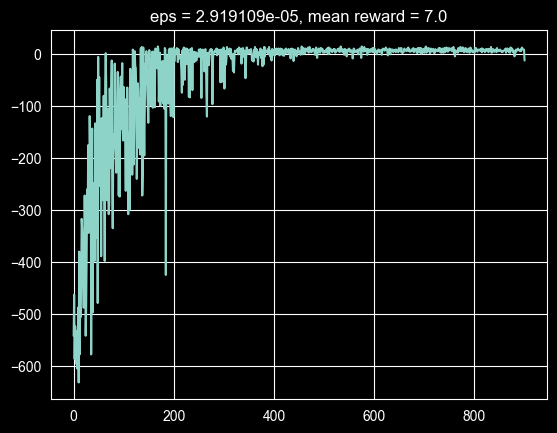

In [13]:
from IPython.display import clear_output
rewards = []
for i in range(1000):
    rewards.append(play_and_train(env, agent))
    agent.epsilon *= 0.99
    if i % 100 == 0:
        clear_output(True)
        plt.title('eps = {:e}, mean reward = {:.1f}'.format(agent.epsilon, np.mean(rewards[-10:])))
        plt.plot(rewards)
        plt.show()

Бинаризованные пространства состояний

first state: [ 0.01827351 -0.01341813 -0.04480666  0.03509564]


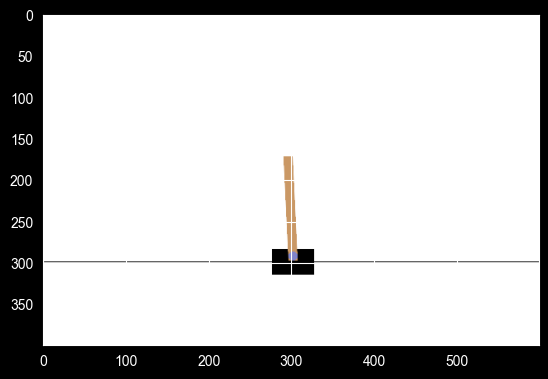

In [14]:
def make_env():
    return gym.make('CartPole-v1', render_mode='rgb_array')
env = make_env()
obs, info = env.reset()
print("first state: %s" % obs)
plt.imshow(env.render())

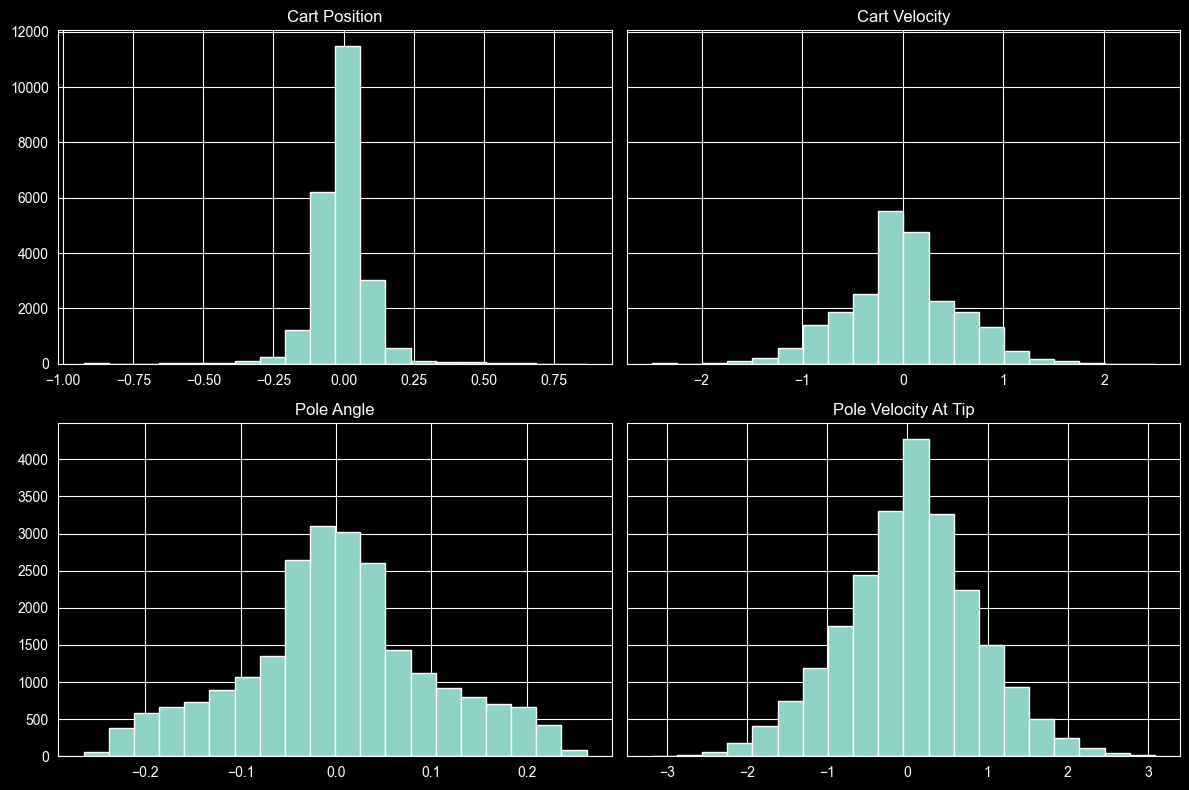

In [15]:
import matplotlib.pyplot as plt
import numpy as np

seen_observations = []

for _ in range(1000):
    obs, _ = env.reset()
    seen_observations.append(obs)

    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = env.action_space.sample()
        s, r, terminated, truncated, _ = env.step(action)
        seen_observations.append(s)

seen_observations = np.array(seen_observations)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
axes = axes.flatten()

titles = [
    "Cart Position",
    "Cart Velocity",
    "Pole Angle",
    "Pole Velocity At Tip"
]

for i in range(4):
    axes[i].hist(seen_observations[:, i], bins=20)
    axes[i].set_title(titles[i])
    axes[i].grid(True)

plt.tight_layout()
plt.show()

Бинаризованная среда

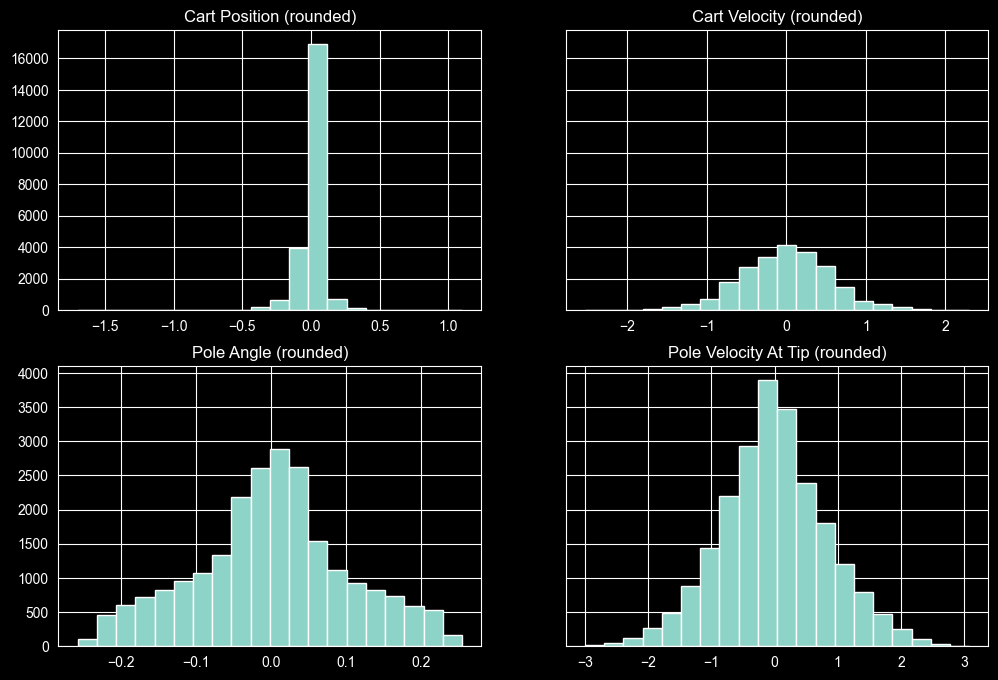

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from gymnasium import ObservationWrapper


class Binarizer(ObservationWrapper):
    def observation(self, state):
        n_digits = [1, 2, 3, 2]
        return tuple(round(x, digits) for x, digits in zip(state, n_digits))


env2 = Binarizer(gym.make('CartPole-v1'))

seen_observations = []

for _ in range(1000):
    obs, _ = env2.reset()
    seen_observations.append(obs)

    terminated = False
    truncated = False

    while not (terminated or truncated):
        action = env2.action_space.sample()
        s, r, terminated, truncated, _ = env2.step(action)
        seen_observations.append(s)

seen_observations = np.array(seen_observations)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey='row')
axes = axes.flatten()

titles = [
    "Cart Position (rounded)",
    "Cart Velocity (rounded)",
    "Pole Angle (rounded)",
    "Pole Velocity At Tip (rounded)"
]

for i in range(4):
    axes[i].hist(seen_observations[:, i], bins=20)
    axes[i].set_title(titles[i])
    axes[i].grid(True)